# Stage 3 — Evaluation
**aero-fno** · Evaluate the FNO v3 surrogate on the held-out test set (90 samples)

**What this notebook does:**
1. Loads `best_model_v3.pt` from Drive
2. Evaluates on `data/test/` — 90 samples never seen during training
3. Compares FNO against a mean-field baseline
4. Per-channel error breakdown (Cp, u*, v*)
5. Visual prediction comparisons
6. Error distribution analysis
7. Performance vs flow conditions (Re, AoA)

In [1]:
# ── 0. Install & Mount ─────────────────────────────────────────────────────────
!pip install neuraloperator -q

from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_DIR   = '/content/drive/MyDrive/aero-fno'
CONTENT_DIR = '/content'

if not os.path.exists('/content/data/train'):
    print('Extracting data...')
    os.system(f'tar -xzf "{DRIVE_DIR}/data_upload.tar.gz" -C "{CONTENT_DIR}"')
    print('Done.')
else:
    print('Data already extracted.')

n_train = len([f for f in os.listdir('/content/data/train') if f.endswith('.npz')])
n_test  = len([f for f in os.listdir('/content/data/test')  if f.endswith('.npz')])
print(f'Train files : {n_train}')
print(f'Test files  : {n_test}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 6.9 MB/s eta 0:00:00
Mounted at /content/drive
Extracting data...
Done.
Train files : 6400
Test files  : 90


In [2]:
# ── 1. Imports & Device ────────────────────────────────────────────────────────
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from neuralop.models import FNO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : Tesla T4


In [3]:
# ── 2. AirfoilDataset v3 (same as Stage 2) ─────────────────────────────────────
class AirfoilDataset(Dataset):
    def __init__(self, data_dir, split='train', val_ratio=0.2, test=False):
        if test:
            # Load from data/test/ directly — all 90 samples
            self.files = sorted(glob.glob(os.path.join(data_dir, '**', '*.npz'), recursive=True))
        else:
            all_files = sorted(glob.glob(os.path.join(data_dir, '**', '*.npz'), recursive=True))
            n_val     = max(1, int(len(all_files) * val_ratio))
            n_train   = len(all_files) - n_val
            self.files = all_files[:n_train] if split == 'train' else all_files[n_train:]

        if not self.files:
            raise FileNotFoundError(f'No .npz files found under: {data_dir}')

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        arr   = np.load(self.files[idx])['a'].astype(np.float32)
        Ux    = float(arr[0].mean())
        Uy    = float(arr[1].mean())
        U_inf = max(float(np.sqrt(Ux**2 + Uy**2)), 1e-6)
        q_inf = max(0.5 * 1.225 * U_inf**2, 1e-6)
        p_inf = float(np.mean([
            arr[3][:8,  :8].mean(), arr[3][:8,  -8:].mean(),
            arr[3][-8:, :8].mean(), arr[3][-8:, -8:].mean(),
        ]))

        inp = np.stack([
            arr[0] / U_inf,
            arr[1] / U_inf,
            arr[2],
        ], axis=0).astype(np.float32)

        Cp  = (arr[3] - p_inf) / q_inf
        u_s = arr[4] / U_inf
        v_s = arr[5] / U_inf
        out = np.stack([Cp, u_s, v_s], axis=0).astype(np.float32)

        return torch.from_numpy(inp), torch.from_numpy(out)

    def get_flow_conditions(self, idx):
        """Return U_inf, AoA, Re from filename."""
        name  = os.path.splitext(os.path.basename(self.files[idx]))[0]
        parts = name.split('_')
        re    = float(parts[-2]) / 100
        aoa   = float(parts[-1]) / 100
        arr   = np.load(self.files[idx])['a'].astype(np.float32)
        U_inf = float(np.sqrt(arr[0].mean()**2 + arr[1].mean()**2))
        return U_inf, aoa, re


# Load test dataset
TEST_DIR = '/content/data/test'
test_ds  = AirfoilDataset(TEST_DIR, test=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f'Test samples : {len(test_ds)}')
x0, y0 = test_ds[0]
print(f'Input  shape : {tuple(x0.shape)}')
print(f'Output shape : {tuple(y0.shape)}')

Test samples : 90
Input  shape : (3, 128, 128)
Output shape : (3, 128, 128)


In [4]:
# ── 3. Load FNO v3 ─────────────────────────────────────────────────────────────
CKPT_PATH = '/content/drive/MyDrive/aero-fno/checkpoints_v3/best_model_v3.pt'

model = FNO(
    n_modes=(48, 48),
    in_channels=3,
    out_channels=3,
    hidden_channels=64,
    n_layers=6,
).to(device)

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f'Loaded best_model_v3.pt')
print(f'Trained for  : {ckpt["epoch"]} epochs')
print(f'Best val loss: {ckpt["val_loss"]:.4f}')
print(f'Parameters   : {sum(p.numel() for p in model.parameters()):,}')

Loaded best_model_v3.pt
Trained for  : 48 epochs
Best val loss: 0.1291
Parameters   : 29,559,427


In [5]:
# ── 4. Baseline — Mean Field Predictor ────────────────────────────────────────
# A trivial baseline: always predict the mean output field from the training set
# If FNO can't beat this, it hasn't learned anything useful

print('Computing mean field from training set...')
TRAIN_DIR = '/content/data/train'
train_ds  = AirfoilDataset(TRAIN_DIR, split='train', val_ratio=0.2)

mean_field = torch.zeros(3, 128, 128)
count = 0
for i in tqdm(range(len(train_ds))):
    _, y = train_ds[i]
    mean_field += y
    count += 1
mean_field /= count
mean_field = mean_field.unsqueeze(0)   # (1, 3, 128, 128)

print(f'Mean field computed over {count} training samples')
print(f'Mean Cp range: [{mean_field[0,0].min():.3f}, {mean_field[0,0].max():.3f}]')

Computing mean field from training set...


100%|██████████| 5120/5120 [00:23<00:00, 221.99it/s]

Mean field computed over 5120 training samples
Mean Cp range: [-1.667, 0.068]


In [6]:
# ── 5. Evaluate FNO vs Baseline on Test Set ────────────────────────────────────
def relative_l2(pred, target, eps=1e-8):
    diff  = pred - target
    num   = diff.pow(2).sum(dim=(-2,-1)).sqrt()
    denom = target.pow(2).sum(dim=(-2,-1)).sqrt() + eps
    return (num / denom)

CHANNEL_NAMES = ['Cp', 'u*', 'v*']

fno_errors      = [[] for _ in range(3)]
baseline_errors = [[] for _ in range(3)]
all_preds       = []
all_targets     = []

model.eval()
with torch.no_grad():
    for x_b, y_b in tqdm(test_loader, desc='Evaluating'):
        x_b    = x_b.to(device)
        pred_b = model(x_b).cpu()
        base_b = mean_field.expand(y_b.shape[0], -1, -1, -1)

        for c in range(3):
            fno_err  = relative_l2(pred_b[:, c:c+1], y_b[:, c:c+1])
            base_err = relative_l2(base_b[:, c:c+1], y_b[:, c:c+1])
            fno_errors[c].extend(fno_err.squeeze().tolist())
            baseline_errors[c].extend(base_err.squeeze().tolist())

        all_preds.append(pred_b)
        all_targets.append(y_b)

all_preds   = torch.cat(all_preds,   dim=0)   # (90, 3, 128, 128)
all_targets = torch.cat(all_targets, dim=0)

print('\nTest Set Results — Relative L2 Error')
print('='*55)
print(f'{"Channel":<12} {"FNO v3":>10} {"Baseline":>10} {"Improvement":>12}')
print('-'*55)
for c, name in enumerate(CHANNEL_NAMES):
    fno_mean  = np.mean(fno_errors[c])
    base_mean = np.mean(baseline_errors[c])
    improv    = (base_mean - fno_mean) / base_mean * 100
    flag      = '✓' if fno_mean < 0.15 else ('~' if fno_mean < 0.30 else '✗')
    print(f'{flag} {name:<10} {fno_mean*100:>9.1f}% {base_mean*100:>9.1f}% {improv:>11.1f}%')
print('='*55)

Evaluating: 100%|██████████| 12/12 [00:01<00:00,  6.09it/s]


Test Set Results — Relative L2 Error
Channel          FNO v3   Baseline  Improvement
-------------------------------------------------------
~ Cp              21.2%      99.7%        78.8%
✓ u*               4.9%      20.1%        75.7%
✓ v*              10.0%      96.2%        89.6%


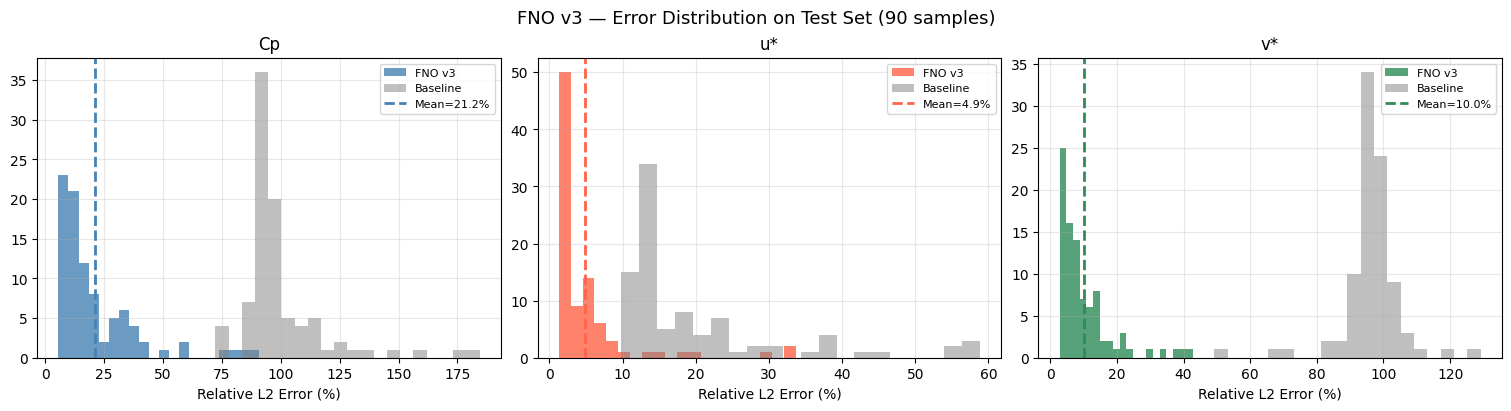

In [7]:
# ── 6. Error Distribution Plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
fig.suptitle('FNO v3 — Error Distribution on Test Set (90 samples)', fontsize=13)

colors = ['steelblue', 'tomato', 'seagreen']
for c, (name, color) in enumerate(zip(CHANNEL_NAMES, colors)):
    axes[c].hist(np.array(fno_errors[c])*100, bins=20, color=color, alpha=0.8, label='FNO v3')
    axes[c].hist(np.array(baseline_errors[c])*100, bins=20, color='gray', alpha=0.5, label='Baseline')
    axes[c].axvline(np.mean(fno_errors[c])*100, color=color, linestyle='--', linewidth=2,
                    label=f'Mean={np.mean(fno_errors[c])*100:.1f}%')
    axes[c].set_xlabel('Relative L2 Error (%)')
    axes[c].set_title(name)
    axes[c].legend(fontsize=8)
    axes[c].grid(alpha=0.3)

plt.savefig(os.path.join(DRIVE_DIR, 'stage3_error_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

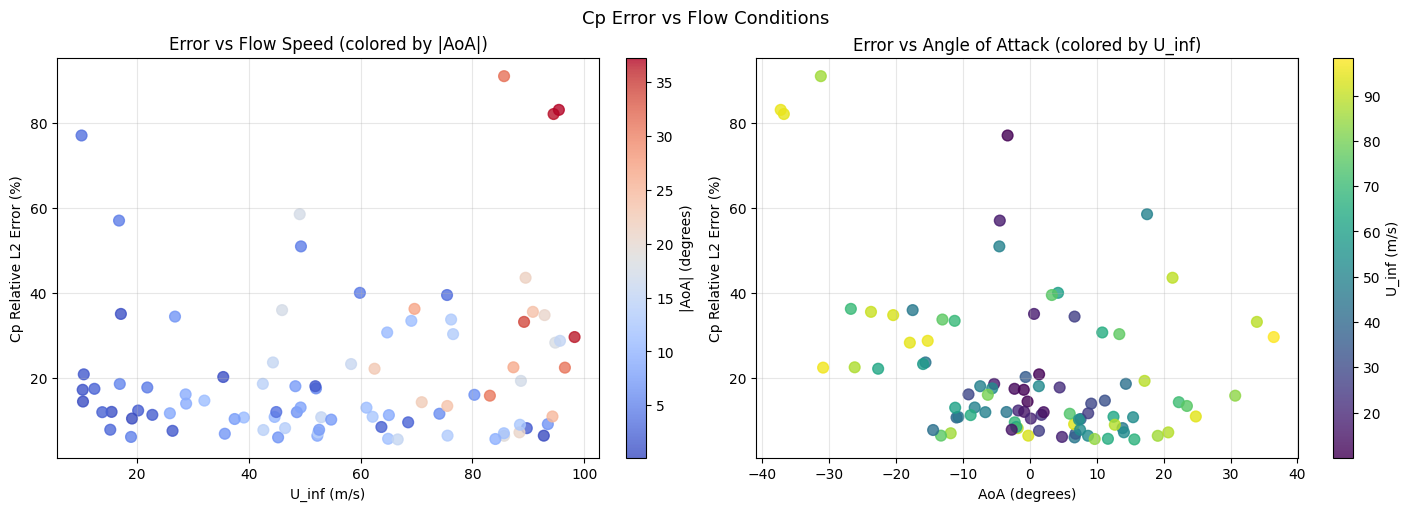

Correlation: Cp error vs U_inf : 0.156
Correlation: Cp error vs |AoA| : 0.411
(values near ±1 mean error strongly depends on that condition)


In [8]:
# ── 7. Error vs Flow Conditions ────────────────────────────────────────────────
# Does error depend on Re or AoA? If so, we know where the model is weakest.

u_infs, aoas, res = [], [], []
for i in range(len(test_ds)):
    u, a, r = test_ds.get_flow_conditions(i)
    u_infs.append(u); aoas.append(a); res.append(r)

u_infs = np.array(u_infs)
aoas   = np.array(aoas)
cp_err = np.array(fno_errors[0]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle('Cp Error vs Flow Conditions', fontsize=13)

sc0 = axes[0].scatter(u_infs, cp_err, c=np.abs(aoas), cmap='coolwarm', alpha=0.8, s=60)
axes[0].set_xlabel('U_inf (m/s)')
axes[0].set_ylabel('Cp Relative L2 Error (%)')
axes[0].set_title('Error vs Flow Speed (colored by |AoA|)')
axes[0].grid(alpha=0.3)
plt.colorbar(sc0, ax=axes[0], label='|AoA| (degrees)')

sc1 = axes[1].scatter(aoas, cp_err, c=u_infs, cmap='viridis', alpha=0.8, s=60)
axes[1].set_xlabel('AoA (degrees)')
axes[1].set_ylabel('Cp Relative L2 Error (%)')
axes[1].set_title('Error vs Angle of Attack (colored by U_inf)')
axes[1].grid(alpha=0.3)
plt.colorbar(sc1, ax=axes[1], label='U_inf (m/s)')

plt.savefig(os.path.join(DRIVE_DIR, 'stage3_error_vs_conditions.png'), dpi=120, bbox_inches='tight')
plt.show()

# Correlation analysis
print(f'Correlation: Cp error vs U_inf : {np.corrcoef(u_infs, cp_err)[0,1]:.3f}')
print(f'Correlation: Cp error vs |AoA| : {np.corrcoef(np.abs(aoas), cp_err)[0,1]:.3f}')
print('(values near ±1 mean error strongly depends on that condition)')

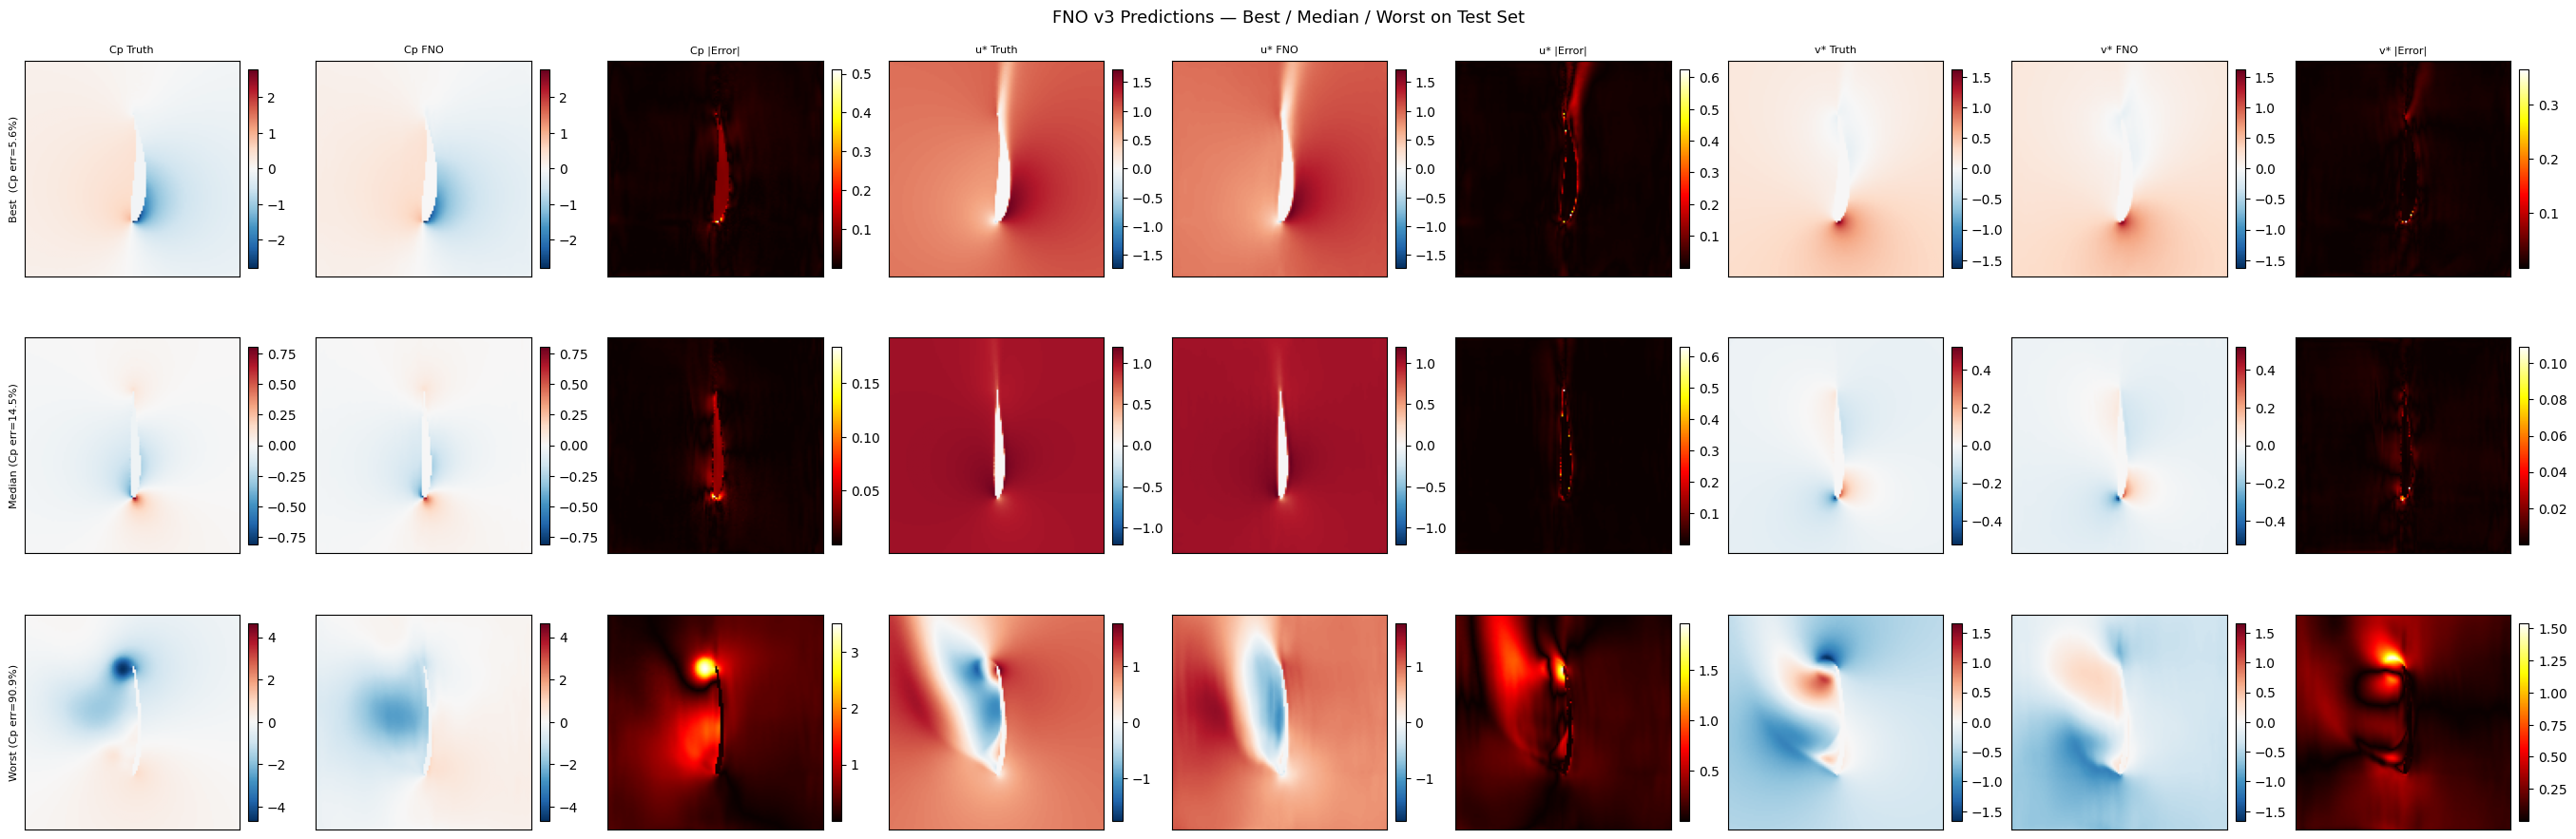

In [9]:
# ── 8. Visual Predictions — Best, Median, Worst ────────────────────────────────
# Show 3 test samples: best prediction, median, worst

cp_errors_per_sample = np.array(fno_errors[0])
sorted_idx = np.argsort(cp_errors_per_sample)
best_idx   = sorted_idx[0]
median_idx = sorted_idx[len(sorted_idx)//2]
worst_idx  = sorted_idx[-1]

cases = [
    (best_idx,   f'Best  (Cp err={cp_errors_per_sample[best_idx]*100:.1f}%)'),
    (median_idx, f'Median (Cp err={cp_errors_per_sample[median_idx]*100:.1f}%)'),
    (worst_idx,  f'Worst (Cp err={cp_errors_per_sample[worst_idx]*100:.1f}%)'),
]

fig, axes = plt.subplots(3, 9, figsize=(27, 9), constrained_layout=True)
fig.suptitle('FNO v3 Predictions — Best / Median / Worst on Test Set', fontsize=13)

ch_names = ['Cp', 'u*', 'v*']
cmaps    = ['RdBu_r', 'RdBu_r', 'RdBu_r']

for row, (idx, label) in enumerate(cases):
    gt   = all_targets[idx]   # (3, 128, 128)
    pr   = all_preds[idx]

    for c in range(3):
        gt_c  = gt[c].numpy()
        pr_c  = pr[c].numpy()
        err_c = np.abs(gt_c - pr_c)
        vmax  = max(np.abs(gt_c).max(), 0.01)

        col_gt  = c * 3
        col_pr  = c * 3 + 1
        col_err = c * 3 + 2

        im0 = axes[row, col_gt ].imshow(gt_c,  origin='lower', cmap=cmaps[c], vmin=-vmax, vmax=vmax)
        im1 = axes[row, col_pr ].imshow(pr_c,  origin='lower', cmap=cmaps[c], vmin=-vmax, vmax=vmax)
        im2 = axes[row, col_err].imshow(err_c, origin='lower', cmap='hot')

        if row == 0:
            axes[row, col_gt ].set_title(f'{ch_names[c]} Truth',  fontsize=8)
            axes[row, col_pr ].set_title(f'{ch_names[c]} FNO',    fontsize=8)
            axes[row, col_err].set_title(f'{ch_names[c]} |Error|',fontsize=8)

        if c == 0:
            axes[row, 0].set_ylabel(label, fontsize=8)

        for ax, im in [(axes[row,col_gt],im0),(axes[row,col_pr],im1),(axes[row,col_err],im2)]:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.set_xticks([]); ax.set_yticks([])

plt.savefig(os.path.join(DRIVE_DIR, 'stage3_best_median_worst.png'), dpi=120, bbox_inches='tight')
plt.show()

In [10]:
# ── 9. Inference Speed ─────────────────────────────────────────────────────────
import time

# Warm up GPU
dummy = torch.randn(1, 3, 128, 128).to(device)
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy)

# Time single sample inference
N_TRIALS = 100
times = []
with torch.no_grad():
    for _ in range(N_TRIALS):
        x_single = torch.randn(1, 3, 128, 128).to(device)
        t0 = time.perf_counter()
        _  = model(x_single)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)

print(f'FNO inference time (single sample):')
print(f'  Mean : {np.mean(times):.2f} ms')
print(f'  Std  : {np.std(times):.2f} ms')
print(f'  Min  : {np.min(times):.2f} ms')
print()
print(f'CFD simulation time  : ~minutes to hours')
print(f'FNO surrogate time   : {np.mean(times):.2f} ms')
print(f'Speedup              : ~{60000/np.mean(times):.0f}x (vs 1 min CFD)')

FNO inference time (single sample):
  Mean : 10.10 ms
  Std  : 0.60 ms
  Min  : 9.66 ms

CFD simulation time  : ~minutes to hours
FNO surrogate time   : 10.10 ms
Speedup              : ~5943x (vs 1 min CFD)


In [11]:
# ── 10. Final Summary ──────────────────────────────────────────────────────────
print('='*55)
print('STAGE 3 SUMMARY — FNO v3 on Test Set (90 samples)')
print('='*55)
print()
print('Per-channel relative L2 error:')
for c, name in enumerate(CHANNEL_NAMES):
    fno_mean  = np.mean(fno_errors[c])
    base_mean = np.mean(baseline_errors[c])
    improv    = (base_mean - fno_mean) / base_mean * 100
    print(f'  {name:<6} : {fno_mean*100:.1f}%  (vs baseline {base_mean*100:.1f}%, {improv:.1f}% better)')
print()
print(f'Inference speed : {np.mean(times):.2f} ms per sample')
print()
print('Normalization: physics-based Cp/u*/v* (key contribution)')
print('Architecture : FNO2d, 48 modes, 6 layers, 64 channels')
print('='*55)

STAGE 3 SUMMARY — FNO v3 on Test Set (90 samples)

Per-channel relative L2 error:
  Cp     : 21.2%  (vs baseline 99.7%, 78.8% better)
  u*     : 4.9%  (vs baseline 20.1%, 75.7% better)
  v*     : 10.0%  (vs baseline 96.2%, 89.6% better)

Inference speed : 10.10 ms per sample

Normalization: physics-based Cp/u*/v* (key contribution)
Architecture : FNO2d, 48 modes, 6 layers, 64 channels
